In [3]:
'''
This script is used to do a general comparison in future changes for multiple scenarios

* This is done focusing on general climatologies using mean values for the entire simulation period
* It also produces an analysis of spatial changes
* It has a number of block of codes to analyze one parameter to produce useful information in the decision making for CRIDA

'''
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from scipy import stats
import geopandas as gpd
import read_swat as swat
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

os.chdir("..") # Changing to main SWATPlusForCRIDA

In [5]:
#Functions
def mean_doy(df):
    df["doy"]=df["date"].dt.dayofyear
    return df.groupby("doy").mean().reset_index()

def max_doy(df):
    df["doy"]=df["date"].dt.dayofyear
    return df.groupby("doy").max().reset_index() 

def min_doy(df):
    df["doy"]=df["date"].dt.dayofyear
    return df.groupby("doy").min().reset_index()  

def mean_monthly(df):
    df["month"] = df["date"].dt.month
    return df.groupby("month").mean(numeric_only=True).reset_index()

def min_monthly(df):
    df["month"] = df["date"].dt.month
    return df.groupby("month").min().reset_index()

def max_monthly(df):
    df["month"] = df["date"].dt.month
    return df.groupby("month").max().reset_index()

def ensemble(dict):
    dict = pd.concat(dict.values(), keys=dict.keys())
    ensemble = dict.groupby(level=1).mean(numeric_only=True)
    return ensemble

def ensembleMin(dict):
    dict = pd.concat(dict.values(), keys=dict.keys())
    ensemble = dict.groupby(level=1).min(numeric_only=True)
    return ensemble

def ensembleMax(dict):
    dict = pd.concat(dict.values(), keys=dict.keys())
    ensemble = dict.groupby(level=1).max(numeric_only=True)
    return ensemble

In [6]:
# Models and paths
model_list = ["SAM_44_RCA4_EC_EARTH",
            "SAM_44_RCA4_GFDL",
            "SAM_44_RCA4_HadGEM2",
            "SAM_44_RCA4_IPSL",
            "SAM_44_RCA4_MIROC5"]

scenarios = ["historical",
                 "rcp45",
                 "rcp85"]

models_folder = "data/CaseStudy/Models/katari-swat-crida-spt/scenarios/Toolbox"

model_dirs = []
combinations = []

for model in model_list:
    for scenario in scenarios:
        model_dirs.append(f"{models_folder}/{scenario}_{model}")

for model in model_list:
    for scenario in scenarios:
        combinations.append(f"{scenario}_{model}")

# Changes in the Basin Water Balance (Overall)

<hr>

In [7]:
# Reading annual average and monthly basin water balance values

basin_wb_yr_file = "basin_wb_yr.txt"
basin_wb_yr_dict = {}

c = 0
for scenario in model_dirs:
    basin_wb_yr = swat.swat_table(f"{scenario}/{basin_wb_yr_file}")
    basin_wb_yr_dict[combinations[c]] = basin_wb_yr.dframe
    c += 1
    
basin_wb_mon_file = "basin_wb_mon.txt"
basin_wb_mon_dict = {}

c = 0
for scenario in model_dirs:
    basin_wb_mon = swat.swat_table(f"{scenario}/{basin_wb_mon_file}")
    basin_wb_mon_dict[combinations[c]] = basin_wb_mon.dframe
    c += 1

#### Historical simulation

In [8]:
# Monthly climatology for historical period
historical_clims = {}
historical_maxs = {}
historical_mins = {}
for scenario in combinations:
    if "historical" in scenario:
        df = basin_wb_mon_dict[scenario][["jday",'mon','day','yr','precip','surq_gen','latq','et','perc']].compute()
        dates=pd.to_datetime(dict(year=df.yr, month=df.mon, day=df.day))
        df["date"]=dates
        df = df[['date','precip','surq_gen','latq','et','perc']]
        
        historical_clims[scenario] = mean_monthly(df)
        historical_maxs[scenario] = max_monthly(df)
        historical_mins[scenario] = min_monthly(df)

#### Future scenarios

In [9]:
#Monthly climatology for future scenarios
period = ["2070-01-01","2099-12-31"] # Here, we are considering far future
future_clims = {}
future_maxs = {}
future_mins = {}
    
for combination in combinations:
    if "historical" not in combination:
        
        df = basin_wb_mon_dict[combination][["jday",'mon','day','yr','precip','surq_gen','latq','et','perc']].compute()
        dates=pd.to_datetime(dict(year=df.yr, month=df.mon, day=df.day))
        
        df["date"]=dates
        df = df[['date','precip','surq_gen','latq','et','perc']]
        df = df.loc[df["date"].between(period[0], period[1])]
        
        scenario = combination.split("_")[0]
        
        future_clims[combination] = mean_monthly(df)
        future_maxs[combination] = min_monthly(df)
        future_mins[combination] = max_monthly(df)
        
        

### Plotting comparisons

Text(0.5, 1.0, 'Expected Changes in Surface Runoff - Far future (2100)')

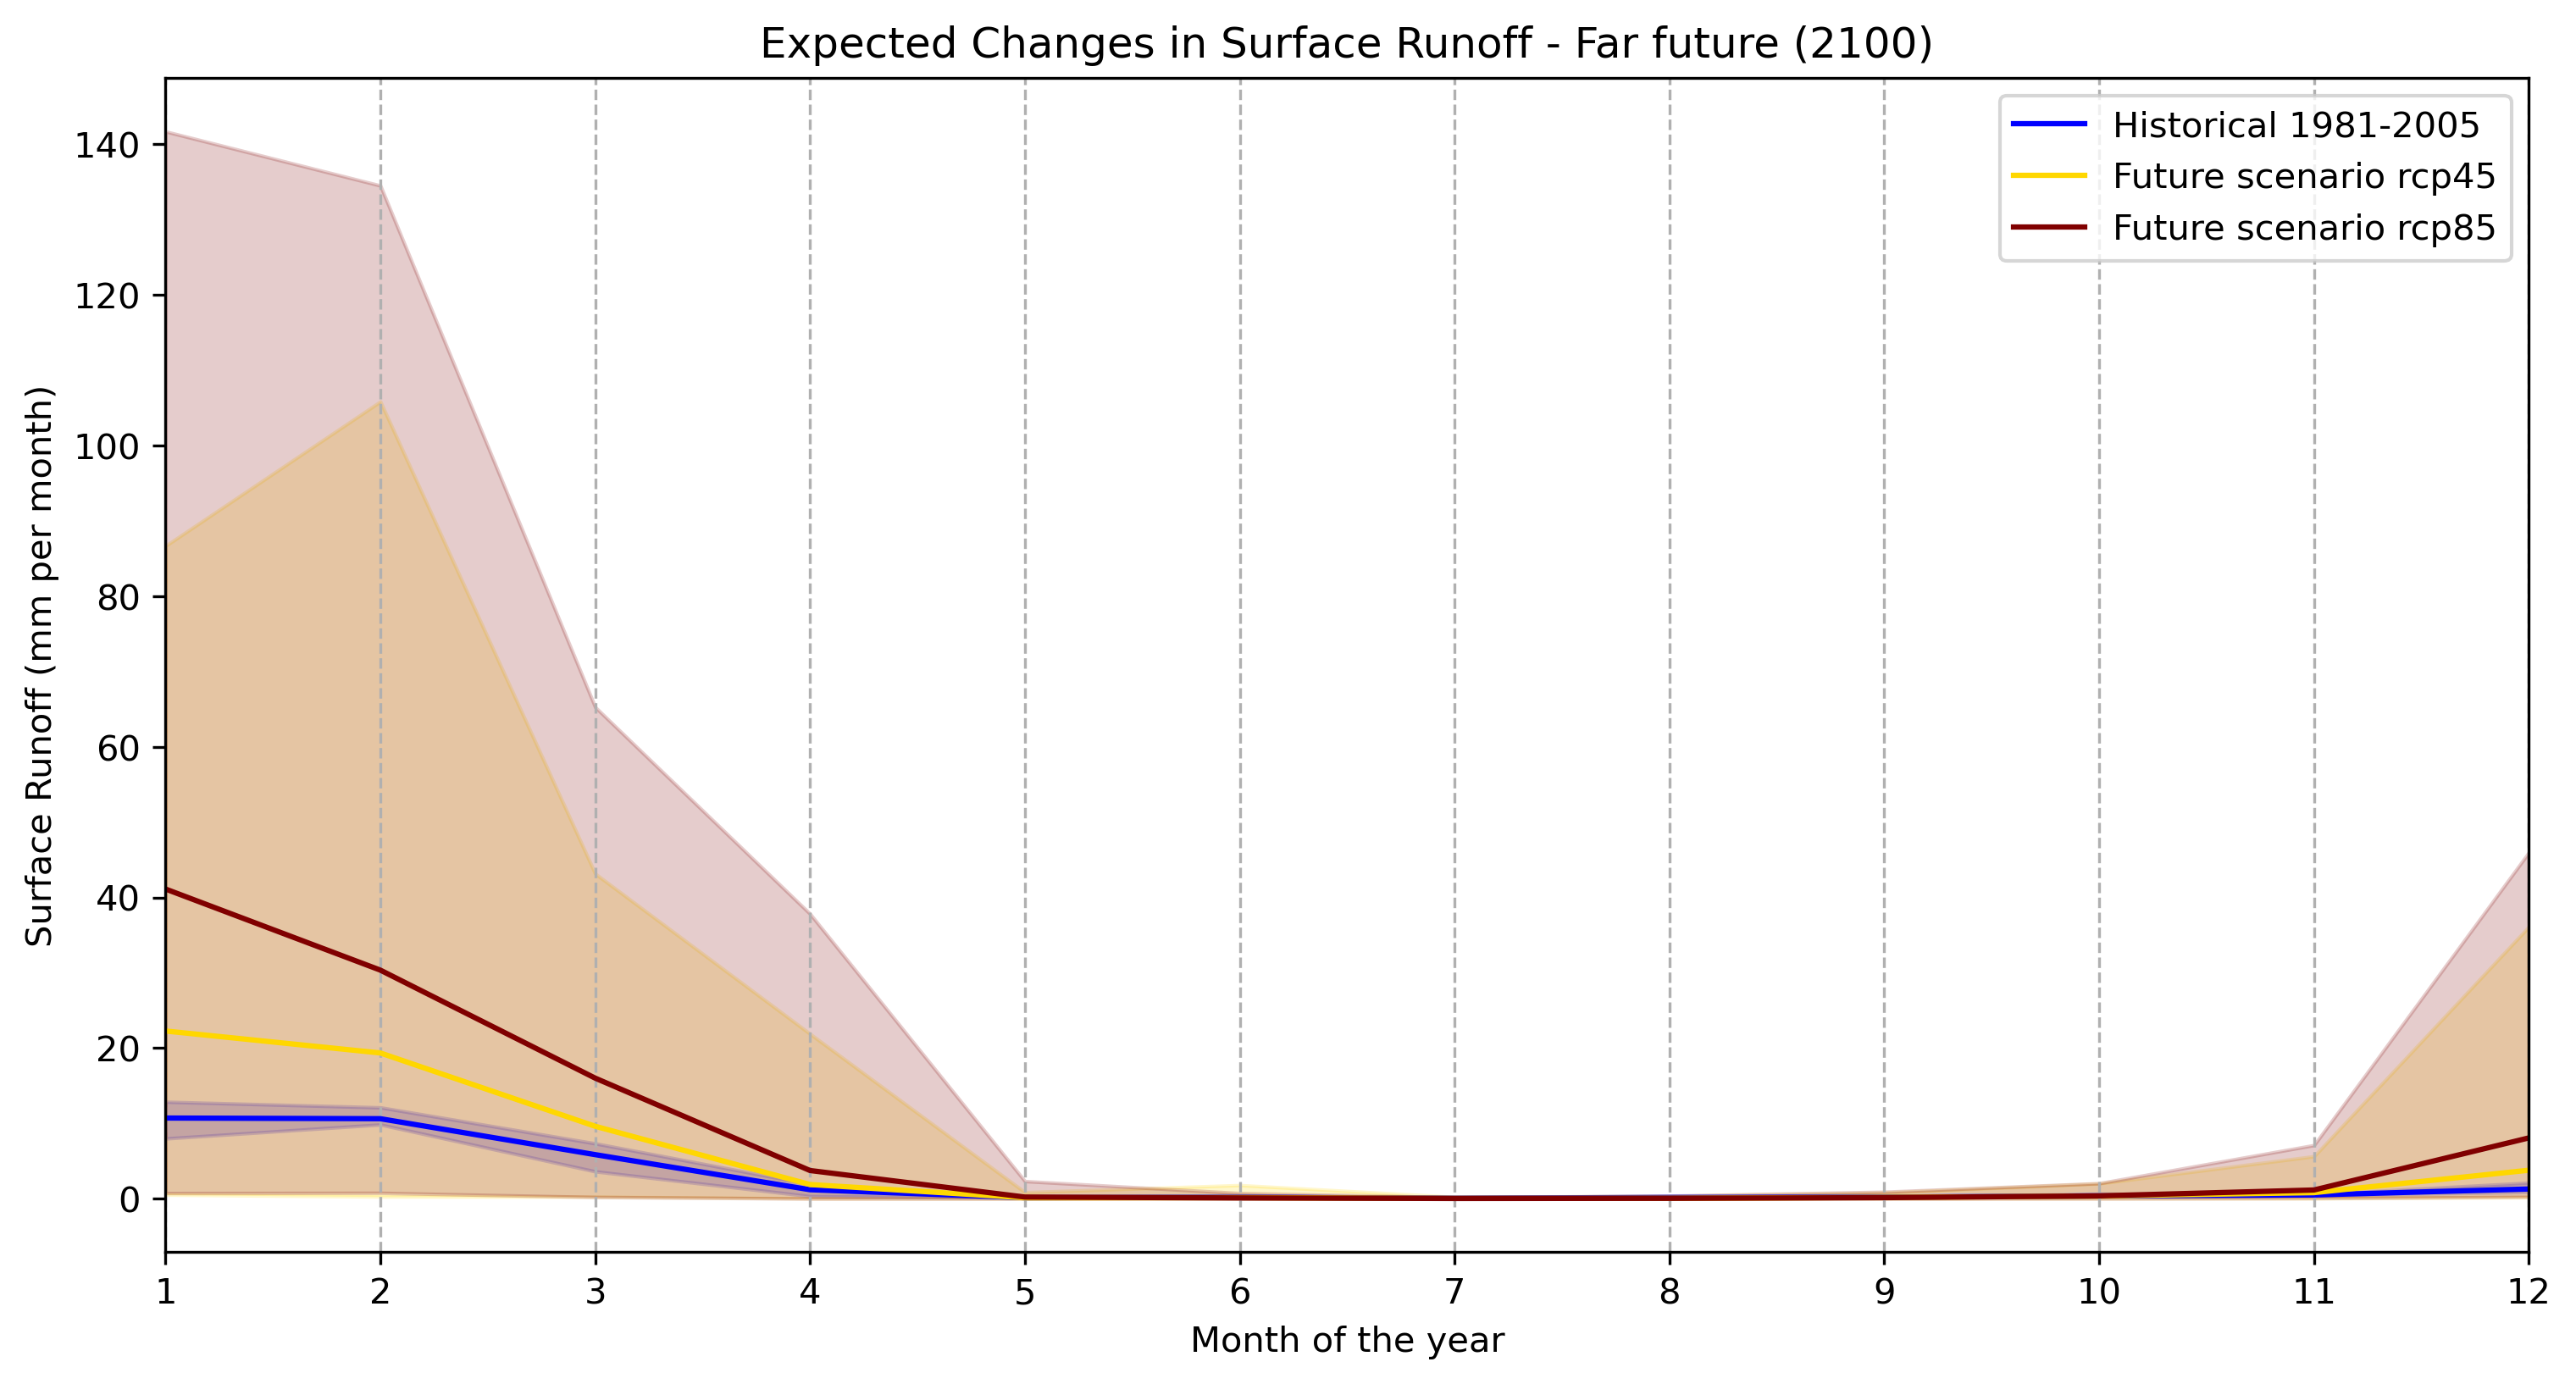

In [10]:
plt.style.use('default')

# Selection of variables and future scenarios
swatvars = ['precip','surq_gen','et','perc','latq']
varnames = ['Precipitation','Surface Runoff', 'ET', 'Percolation', 'Lateral Flow']

scens    = ["rcp45","rcp85"]
colors   = ["gold","maroon"]

time_charac = "Far future (2100)"

varselection = 1
var = swatvars[varselection]
var_name = varnames[varselection]


# Plotting

fig,ax = plt.subplots(figsize=(12,6),dpi=300)
days=np.arange(1,13)
# Getting historical ensemble data
ensemble_clims = ensemble(historical_clims)
ensemble_min = ensembleMin(historical_clims)
ensemble_max = ensembleMax(historical_clims)

ensemble_clims.plot(x="month",y=var,ax=ax,label = f"Historical 1981-2005",color="blue")

ax.fill_between(days,
                ensemble_max[var],
                ensemble_min[var],
                alpha=0.2,color="blue")


c = 0 
for scenario in scens:
    plot_clims = {}
    plot_mins  = {}
    plot_maxs  = {}
    color = colors[c]
    
    for combination in combinations:
        if scenario in combination:
            plot_clims[combination] = future_clims[combination]
            plot_maxs[combination]  = future_maxs[combination]
            plot_mins[combination]  = future_mins[combination]
    
    future_ensemble_clims = ensemble(plot_clims)
    future_ensemble_maxs = ensemble(plot_maxs)
    future_ensemble_mins = ensemble(plot_mins)
    
    future_ensemble_clims.plot(x="month",y=var,ax=ax,label = f"Future scenario {scenario}",color=color)
    
    ax.fill_between(days,
                future_ensemble_maxs[var],
                future_ensemble_mins[var],
                alpha=0.2,color=color)

    c += 1
ax.set_xticks(np.arange(0, 13, 1))

ax.legend(loc="upper right")
ax.grid(True, which='major', axis='x', linestyle='--', alpha=1)
ax.set_xlabel("Month of the year")
ax.set_xlim(1,12)
ax.set_ylabel(f"{var_name} (mm per month)")    
ax.set_title(f"Expected Changes in {var_name} - {time_charac}")    

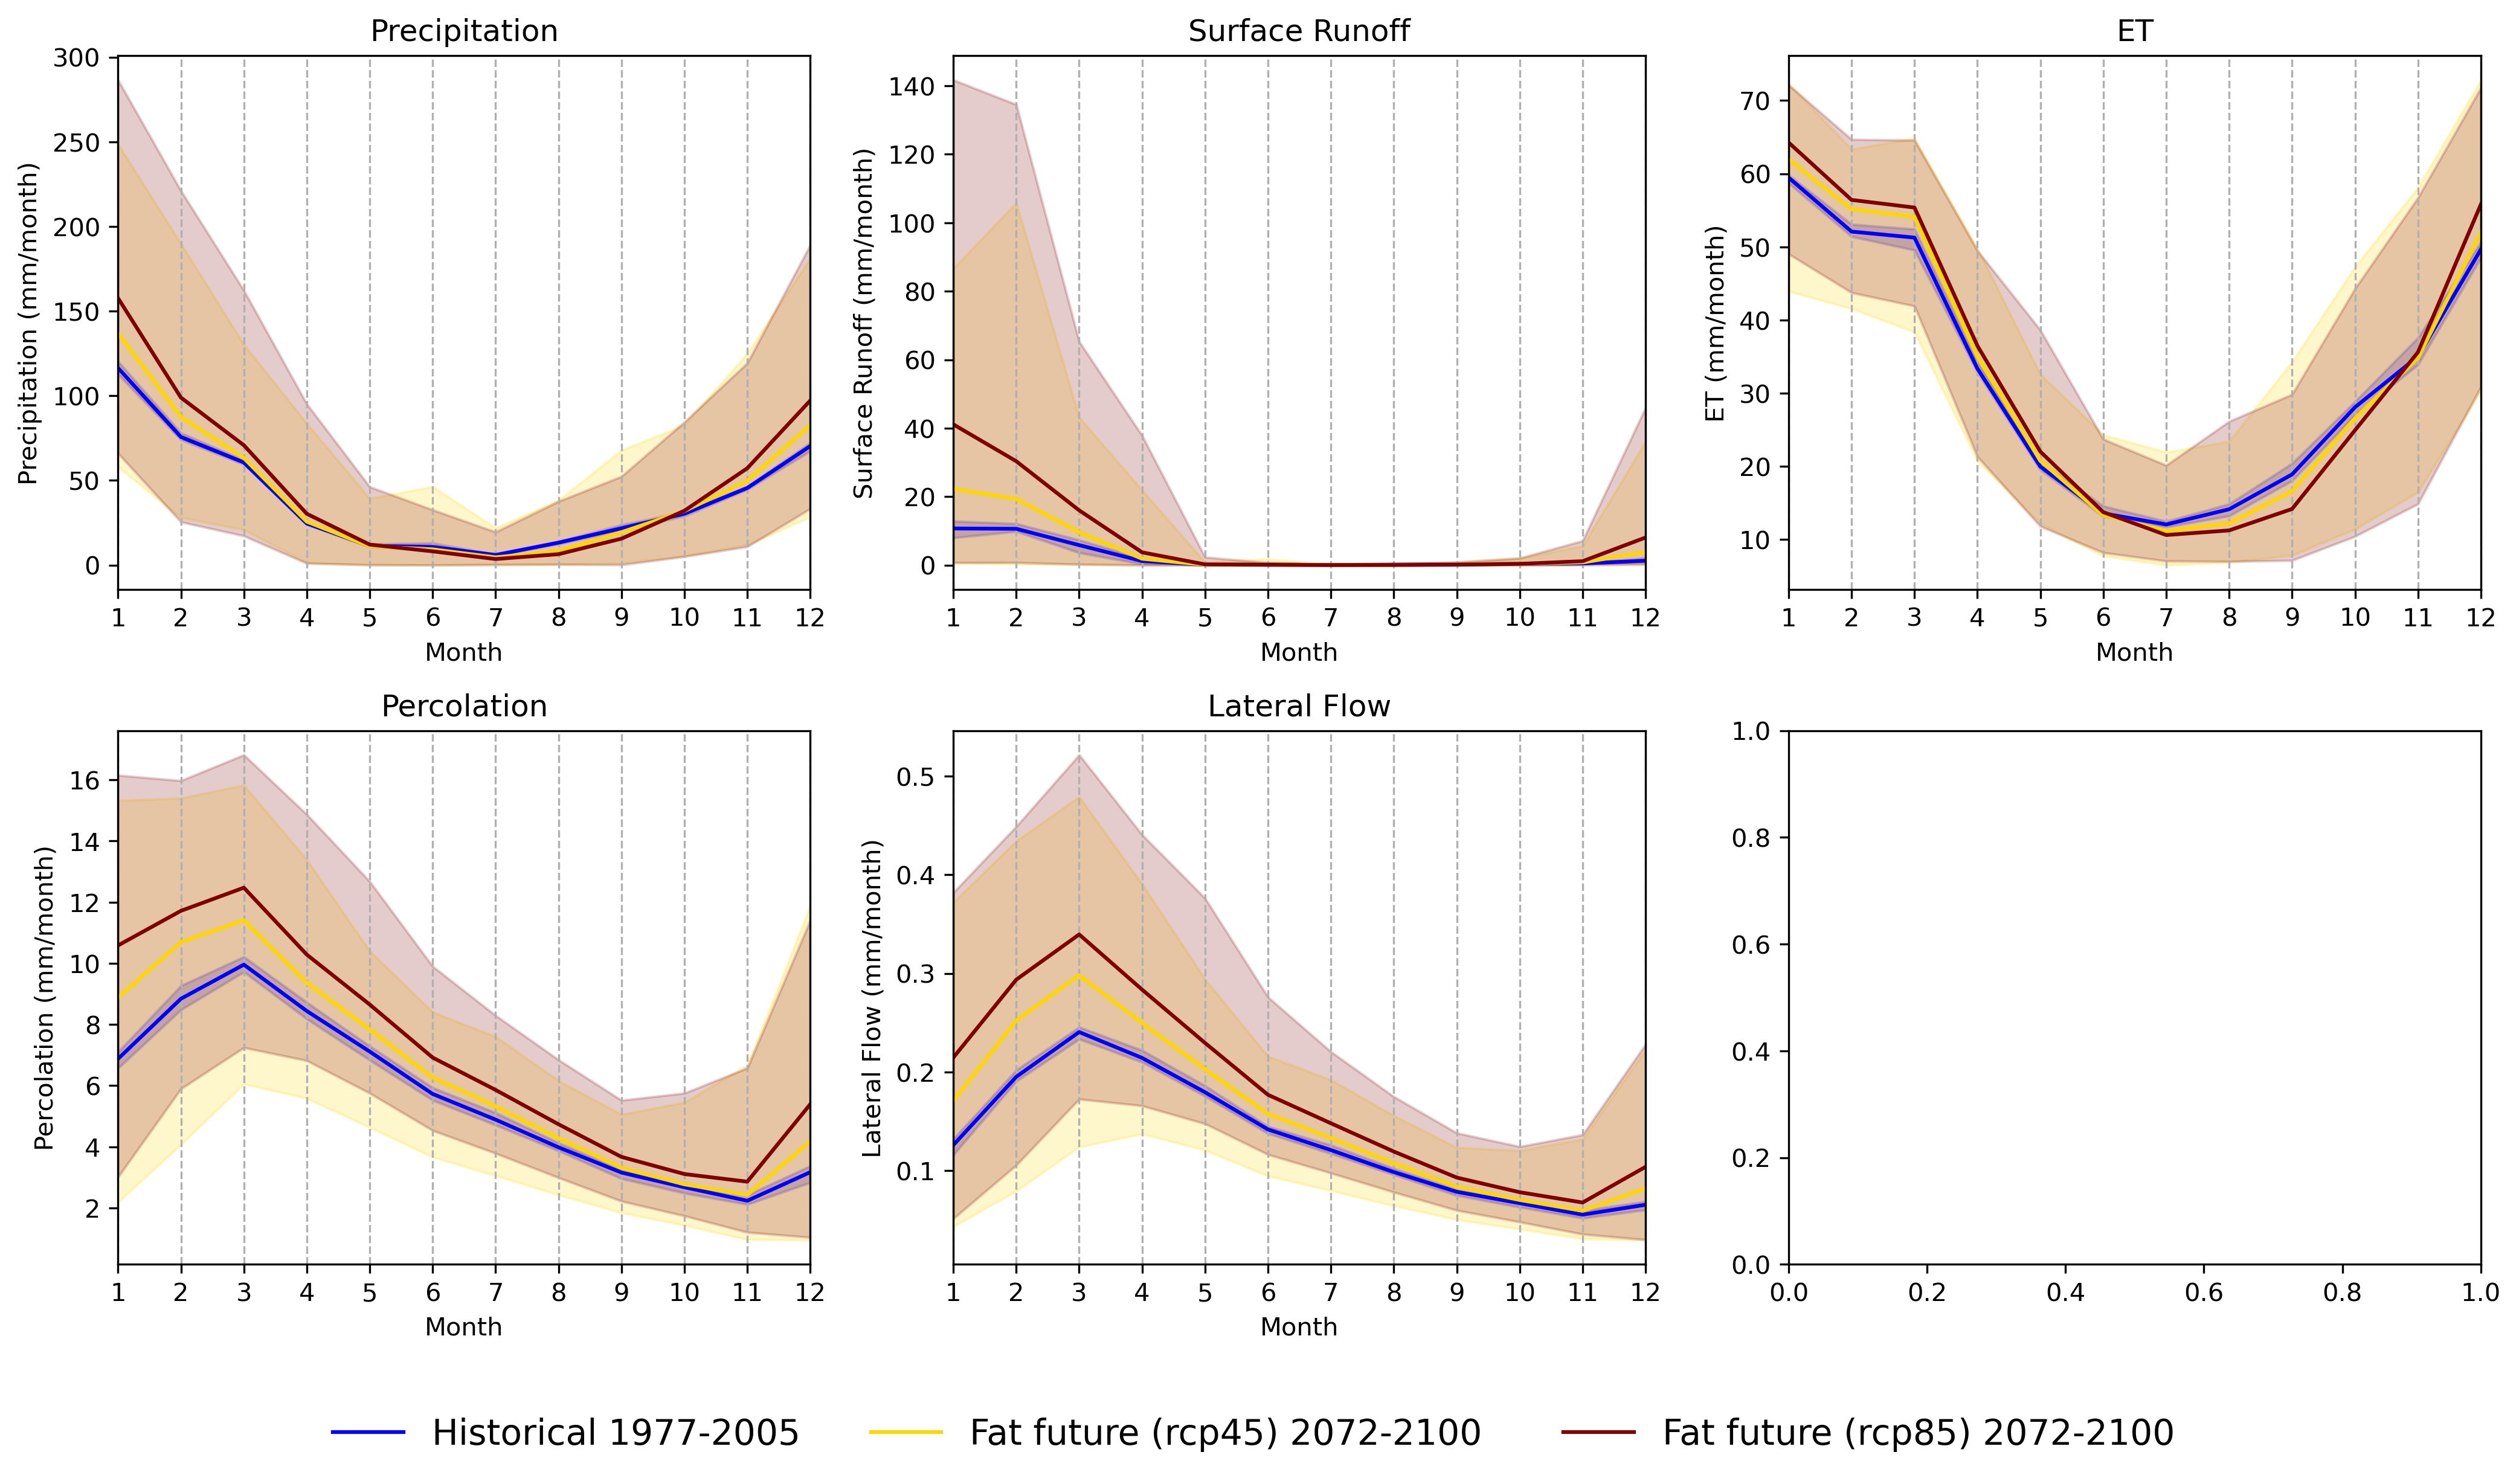

In [25]:
plt.style.use('default')

# Selection of variables and future scenarios
swatvars = ['precip', 'surq_gen', 'et', 'perc','latq']
varnames = ['Precipitation', 'Surface Runoff', 'ET', 'Percolation','Lateral Flow']
scens    = ["rcp45", "rcp85"]
colors   = ["gold", "maroon"]
time_charac = ""
days = np.arange(1, 13)

# Create 2x2 subplot
fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=300)
axes = axes.flatten()

for i, (var, var_name) in enumerate(zip(swatvars, varnames)):
    ax = axes[i]
    
    # Historical ensemble
    ensemble_clims = ensemble(historical_clims)
    ensemble_min = ensembleMin(historical_clims)
    ensemble_max = ensembleMax(historical_clims)
    
    ensemble_clims.plot(x="month", y=var, ax=ax, label="Historical 1977-2005", color="blue", legend=False)
    ax.fill_between(days, ensemble_max[var], ensemble_min[var], alpha=0.2, color="blue")
    
    # Future scenarios
    for c, scenario in enumerate(scens):
        plot_clims = {}
        plot_mins  = {}
        plot_maxs  = {}
        color = colors[c]
        
        for combination in combinations:
            if scenario in combination:
                plot_clims[combination] = future_clims[combination]
                plot_maxs[combination]  = future_maxs[combination]
                plot_mins[combination]  = future_mins[combination]
        
        future_ensemble_clims = ensemble(plot_clims)
        future_ensemble_maxs = ensemble(plot_maxs)
        future_ensemble_mins = ensemble(plot_mins)
        
        future_ensemble_clims.plot(x="month", y=var, ax=ax, label=f"Fat future ({scenario}) 2072-2100 ", color=color, legend=False)
        ax.fill_between(days, future_ensemble_maxs[var], future_ensemble_mins[var], alpha=0.2, color=color)
    
    ax.set_xticks(np.arange(1, 13, 1))
    ax.grid(True, which='major', axis='x', linestyle='--', alpha=1)
    ax.set_xlim(1, 12)
    ax.set_xlabel("Month")
    ax.set_ylabel(f"{var_name} (mm/month)")
    ax.set_title(f"{var_name}")

# Shared legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03),fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 1])


### Plotting in space

In [12]:
# Paths
hru_shp_path = "data/CaseStudy/Models/katari-swat-crida/Watershed/Shapes/hrus2.shp"
hru_wb_yr_file = "hru_wb_yr.txt"

basin_shp_path = "data/CaseStudy/Models/katari-swat-crida/Watershed/Shapes/subs1.shp"
rivs_shp_path = "data/CaseStudy/Models/katari-swat-crida-spt/gis.data/Watershed/Shapes/rivs1.shp"


hrus_gdf = gpd.read_file(hru_shp_path).to_crs(epsg=4326)  # Read shapefile of HRUS
subs_gdf = gpd.read_file(basin_shp_path).to_crs(epsg=4326)  # Read shapefile of basins
rivs_gdf = gpd.read_file(rivs_shp_path).to_crs(epsg=4326)  # Read shapefile of rivers

basin_gdf = subs_gdf.dissolve().boundary

# Select scenario 
future_scen = "rcp45"

In [13]:
#Getting yearly HRU water balance tables
hru_wb_yr_dict = {}
c=0
for dir in model_dirs:
    hru_wb_yr = swat.swat_table(f"{dir}/{hru_wb_yr_file}")
    hru_wb_yr_dict[combinations[c]] = hru_wb_yr.dframe
    c+=1

In [14]:
#Getting annual mean for historical and for 2070-2100 period
historical_hru_mean = {}
future_hru_mean = {}

for scenario in combinations:
    if "historical" in scenario:
        df = hru_wb_yr_dict[scenario][['yr','gis_id','precip','surq_gen','latq','et','perc']].compute()
        df = df[['yr','gis_id','precip','surq_gen','latq','et','perc']]
        historical_hru_mean[scenario] = df

    if future_scen in scenario:
        df = hru_wb_yr_dict[scenario][['yr','gis_id','precip','surq_gen','latq','et','perc']].compute()
        df = df[['yr','gis_id','precip','surq_gen','latq','et','perc']]
        df = df.loc[df["yr"].between(2070, 2099)] 
        future_hru_mean[scenario] = df
        
# Merging with spatial data
ensemble_historical_hru_yr = ensemble(historical_hru_mean)
ensemble_future_hru_yr = ensemble(future_hru_mean)

ensemble_historical_hru = ensemble_historical_hru_yr.groupby("gis_id").mean()[['precip','surq_gen','latq','et','perc']].reset_index()
ensemble_future_hru = ensemble_future_hru_yr.groupby("gis_id").mean()[['precip','surq_gen','latq','et','perc']].reset_index()


hrus_gdf['HRUS']=hrus_gdf['HRUS'].astype(float)

ensemble_historical_hru = ensemble_historical_hru.rename(columns={"gis_id":"HRUS"})
ensemble_future_hru = ensemble_future_hru.rename(columns={"gis_id":"HRUS"})



hrus_historical_gdf = pd.merge(hrus_gdf,ensemble_historical_hru,on="HRUS",how="left")
hrus_historical_gdf = hrus_historical_gdf[['HRUS','precip','surq_gen','latq','et','perc','geometry']]
hrus_historical_gdf = gpd.GeoDataFrame(hrus_historical_gdf,geometry=hrus_gdf['geometry'])


hrus_future_gdf = pd.merge(hrus_gdf,ensemble_future_hru,on="HRUS",how="left")
hrus_future_gdf = hrus_future_gdf[['HRUS','precip','surq_gen','latq','et','perc','geometry']]
hrus_future_gdf = gpd.GeoDataFrame(hrus_future_gdf,geometry=hrus_gdf['geometry'])

In [16]:
swatvars

['precip', 'surq_gen', 'et', 'perc']

### Plotting historical water balance

Text(0.5, 0.93, 'Historical Water Balance (Using RCM Forcings)')

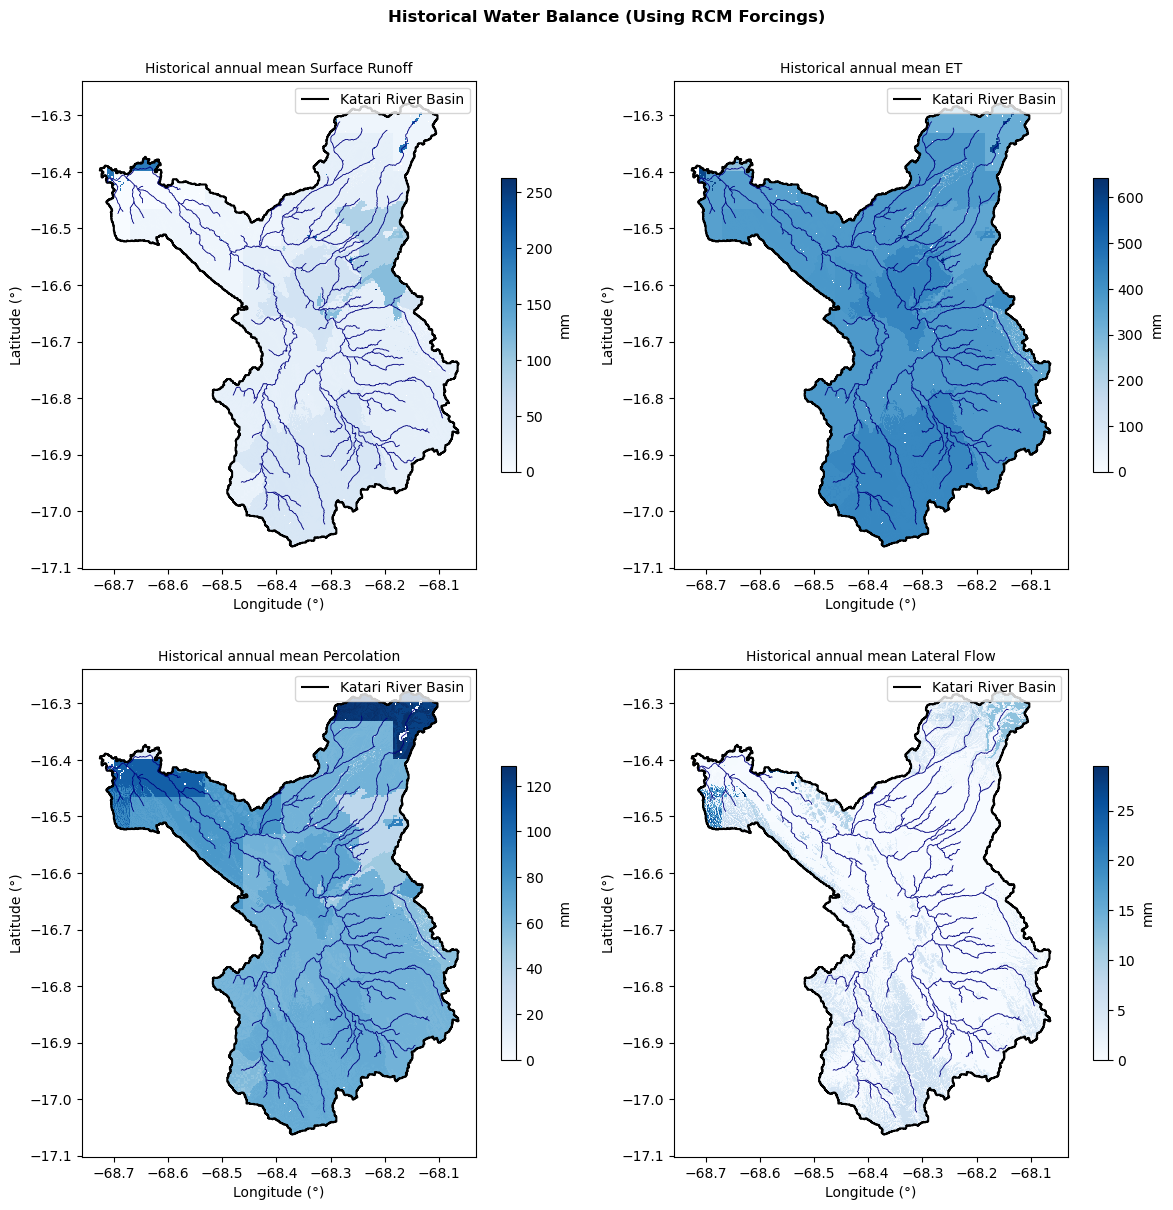

In [26]:
#Plotting mean annual values per HRU
label_basin = "Katari River Basin"
title = "Historical Water Balance (Using RCM Forcings)"
cmap="Blues"  #BuPu is also nice

fig , axs = plt.subplots(2,2,figsize=(14,14))

counter = 0
for ax in axs.flatten():
    leg_kwds={"shrink":0.6,"label":f"mm"}
    hrus_historical_gdf.plot(column=swatvars[counter+1],ax=ax,legend=True,cmap=cmap,vmin = 0,legend_kwds=leg_kwds)
    basin_gdf.plot(ax=ax,color="k",label=label_basin)
    rivs_gdf.plot(ax=ax,color='navy',linewidth=0.6)
    
    
    # ax.set_xlim([-80.6,-79.8])
    # ax.set_ylim([22.2,23])
    ax.set_title(f"Historical annual mean {varnames[counter+1]}",fontsize=10)
    ax.set_ylabel("Latitude (°)")
    ax.set_xlabel("Longitude (°)")
    ax.legend()
    counter += 1

plt.suptitle(title,y=0.93,fontweight="bold")

### Plotting future changes for a selected scenario

In [27]:
# Calculating percentage of change
for var in swatvars:
    hrus_future_gdf[f"c%_{var}"]=(hrus_future_gdf[var]-hrus_historical_gdf[var])/(abs(hrus_historical_gdf[var]))*100

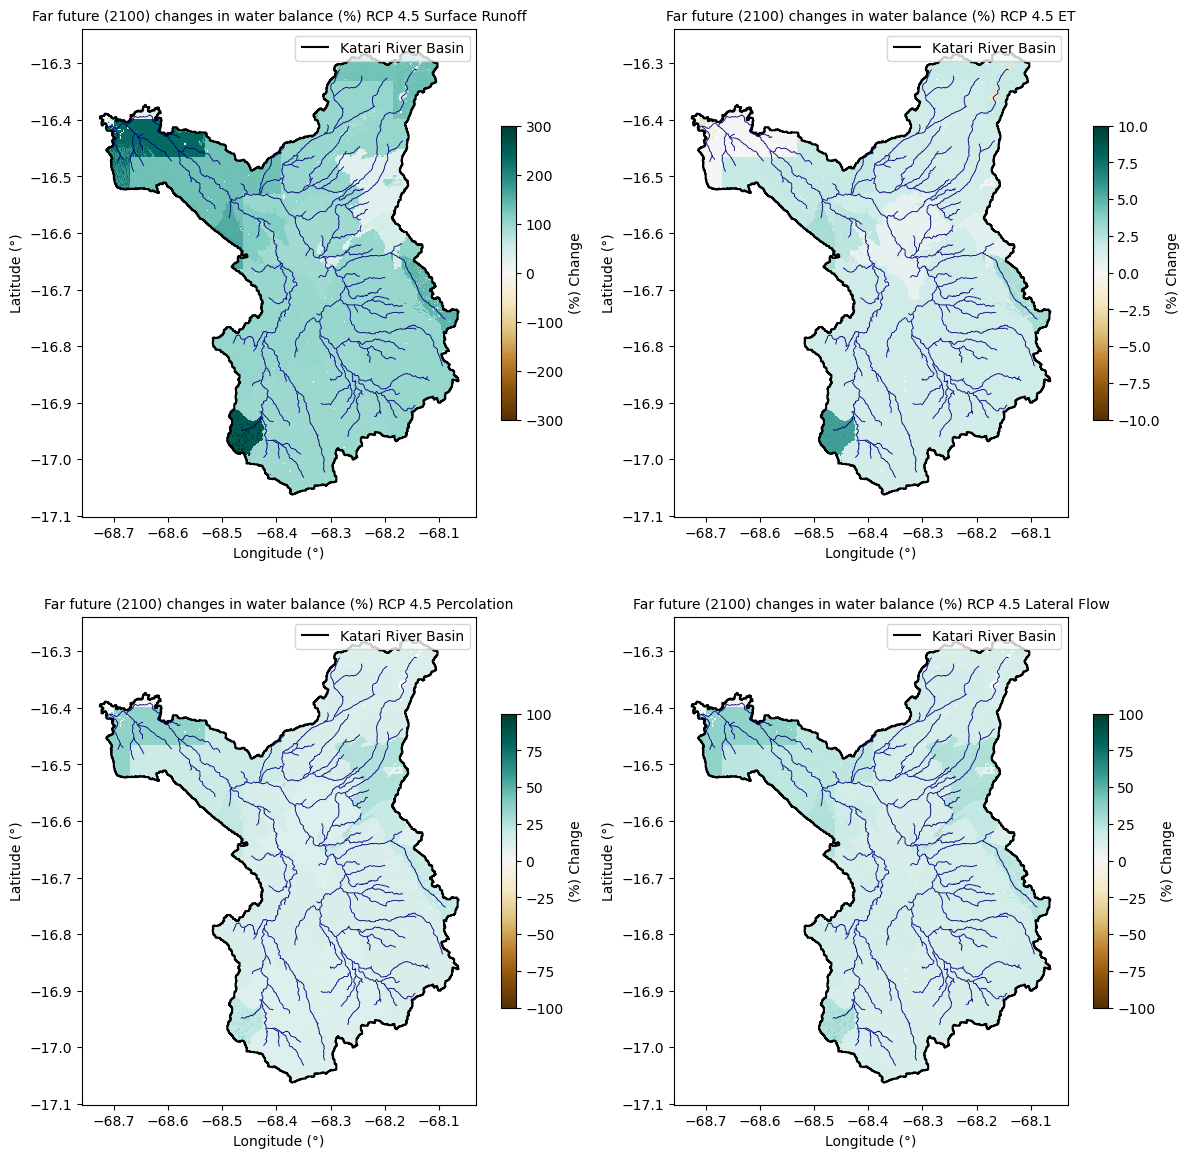

In [28]:
#Plotting mean annual changes (in %) values per HRU
scenario = "RCP 4.5"
title = "Far future (2100) changes in water balance (%)"

# Set limits in order: Surface Runoff, ET, Percolation, Lateral Flow
lims = [[-300,300],[-10,10],[-100,100],[-100,100]]

fig , axs = plt.subplots(2,2,figsize=(14,14))
counter = 0
for ax in axs.flatten():
    leg_kwds={"shrink":0.6,"label":f"(%) Change"}
    hrus_future_gdf.plot(column=f"c%_{swatvars[counter+1]}",ax=ax,legend=True,cmap="BrBG",legend_kwds=leg_kwds,
                              vmin = lims[counter][0],vmax=lims[counter][1])
    basin_gdf.plot(ax=ax,color="k",label=label_basin)
    rivs_gdf.plot(ax=ax,color='navy',linewidth=0.6)
    
    

    ax.set_title(f"{title} {scenario} {varnames[counter+1]}",fontsize=10)
    ax.set_ylabel("Latitude (°)")
    ax.set_xlabel("Longitude (°)")
    ax.legend()
    counter += 1

# Changes in the streamflow at measuring station

<hr>

In [29]:
# Paths & file names
chan_table = "channel_sd_mon.txt" # Instead of mon it can be day

# Set channel number
chan_nr = 47

# Select scenario
future_scen = "rcp45"

scenario = "RCP 4.5" # (For plotting)

### Reading streamflow data for historical and future scenario

In [50]:
chan_hist   = {}
chan_future = {}

for combination in combinations:
    
    if "historical" in combination:
        dir = f"{models_folder}/{combination}"
        chan_hist[combination] = swat.swat_table(f"{dir}/{chan_table}").obj_output(chan_nr,"flo_out")    
        
    if future_scen in combination:
        dir = f"{models_folder}/{combination}"
        chan_future[combination] = swat.swat_table(f"{dir}/{chan_table}").obj_output(chan_nr,"flo_out")
        
    else:
        continue    

In [51]:
# Getting mean, max and min
combined_hist = None
combined_future = None

for combination, df in chan_hist.items():
    df = df.copy()
    df = df.rename(columns={"flo_out": combination})
    
    if combined_hist is None:
        combined_hist = df
    else:
        combined_hist = pd.merge(combined_hist, df, on="date", how="inner")

for combination, df in chan_future.items():
    df = df.copy()
    df = df.rename(columns={"flo_out": combination})
    
    if combined_future is None:
        combined_future = df
    else:
        combined_future = pd.merge(combined_future, df, on="date", how="inner")
        



chan_hist_ens = {
    "mean": combined_hist.drop(columns="date").mean(axis=1),
    "max":  combined_hist.drop(columns="date").max(axis=1),
    "min":  combined_hist.drop(columns="date").min(axis=1)
}

chan_future_ens = {
    "mean": combined_future.drop(columns="date").mean(axis=1),
    "max":  combined_future.drop(columns="date").max(axis=1),
    "min":  combined_future.drop(columns="date").min(axis=1)
}

### Plot hydrograph of ensembles

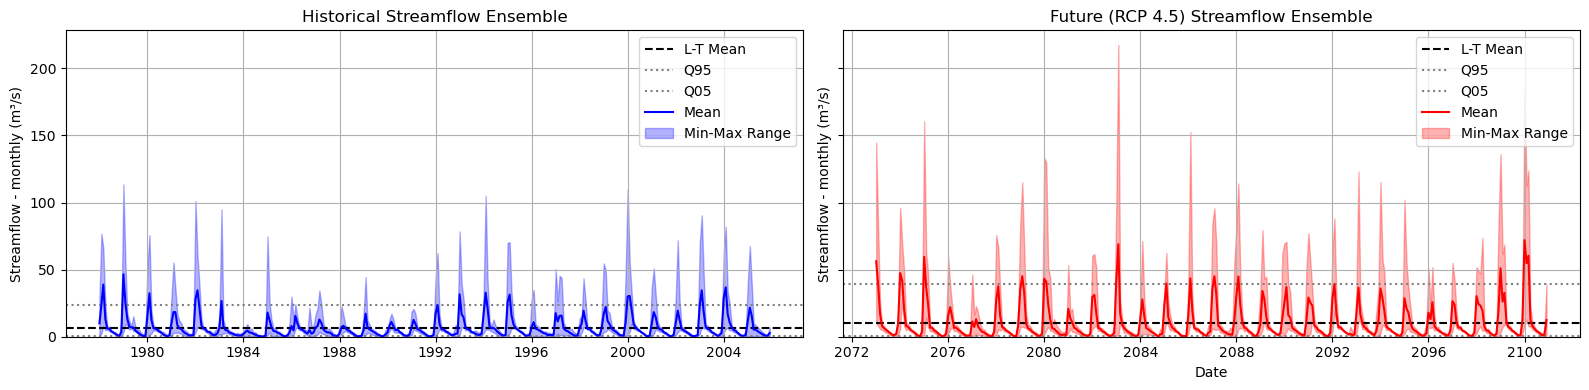

In [55]:
y_limit = (0, 1.05 * max(chan_hist_ens["max"].max(), chan_future_ens["max"].max())) # Can be adjusted

start_hist, end_hist = 1978, 2005
start_fut, end_fut = 2073, 2100
frequency = "monthly"  # or "daily"


# Calculating long term mean and Quantiles (95,05)
mean_hist = chan_hist_ens["mean"].mean()
q95_hist  = chan_hist_ens["mean"].quantile(0.95)
q05_hist  = chan_hist_ens["mean"].quantile(0.05)

mean_fut = chan_future_ens["mean"].mean()
q95_fut  = chan_future_ens["mean"].quantile(0.95)
q05_fut  = chan_future_ens["mean"].quantile(0.05)


# Create time ranges
freq = "MS" if frequency == "monthly" else "D"
date_range_hist = pd.date_range(start=f"{start_hist}-01-01", end=f"{end_hist}-12-01", freq=freq)
date_range_fut  = pd.date_range(start=f"{start_fut}-01-01", end=f"{end_fut}-12-01", freq=freq)

for key in chan_hist_ens:
    chan_hist_ens[key].index = date_range_hist

for key in chan_future_ens:
    chan_future_ens[key].index = date_range_fut


# Plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

# Plotting stat lines
ax1.axhline(mean_hist, linestyle="--", color="black", label="L-T Mean")
ax1.axhline(q95_hist, linestyle=":", color="gray", label="Q95")
ax1.axhline(q05_hist, linestyle=":", color="gray", label="Q05")

ax2.axhline(mean_fut, linestyle="--", color="black", label="L-T Mean")
ax2.axhline(q95_fut, linestyle=":", color="gray", label="Q95")
ax2.axhline(q05_fut, linestyle=":", color="gray", label="Q05")

# Plotting ensembles
ax1.plot(chan_hist_ens["mean"].index, chan_hist_ens["mean"].values, label="Mean", color="blue")
ax1.fill_between(
    chan_hist_ens["mean"].index,
    chan_hist_ens["min"].values,
    chan_hist_ens["max"].values,
    color="blue",
    alpha=0.3,
    label="Min-Max Range"
)
ax1.set_title("Historical Streamflow Ensemble")
ax1.set_ylabel(f"Streamflow - {frequency} (m³/s)")
ax1.set_ylim(y_limit)
ax1.legend()
ax1.grid(True)

ax2.plot(chan_future_ens["mean"].index, chan_future_ens["mean"].values, label="Mean", color="red")
ax2.fill_between(
    chan_future_ens["mean"].index,
    chan_future_ens["min"].values,
    chan_future_ens["max"].values,
    color="red",
    alpha=0.3,
    label="Min-Max Range"
)
ax2.set_title(f"Future ({scenario}) Streamflow Ensemble")
ax2.set_ylabel(f"Streamflow - {frequency} (m³/s)")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True)
ax2.set_ylim(y_limit)


plt.tight_layout()

# Indicator analysis

<hr>

### Checking increase in Q95 overall

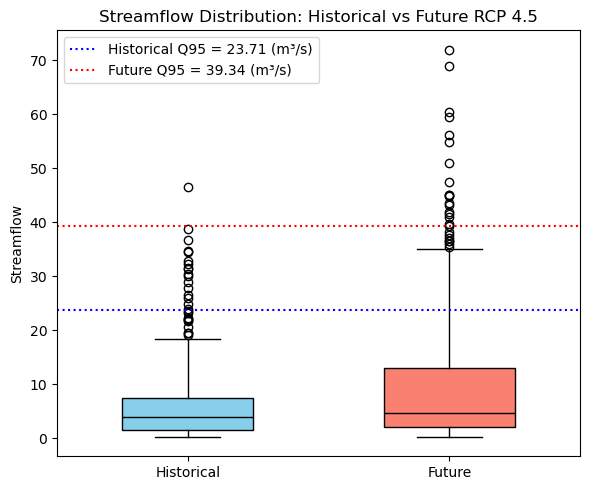

In [56]:
# Box plot to better appreciate changes on long-term indicators
whis = 2 # Interquartile range (IQR)

data = [
    chan_hist_ens["mean"].values,
    chan_future_ens["mean"].values
]

labels = ["Historical", "Future"]

fig, ax = plt.subplots(figsize=(6, 5))
box = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.5,whis=whis,medianprops=dict(color='black'))

colors = ['skyblue', 'salmon']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    

ax.axhline(q95_hist, linestyle=":", color="blue", label=f"Historical Q95 = {q95_hist:.2f} (m³/s)")
ax.axhline(q95_fut, linestyle=":", color="red", label=f"Future Q95 = {q95_fut:.2f} (m³/s)")

ax.set_ylabel("Streamflow")
ax.set_title(f"Streamflow Distribution: Historical vs Future {scenario}")
ax.legend()
plt.tight_layout()

### Q95 Per model

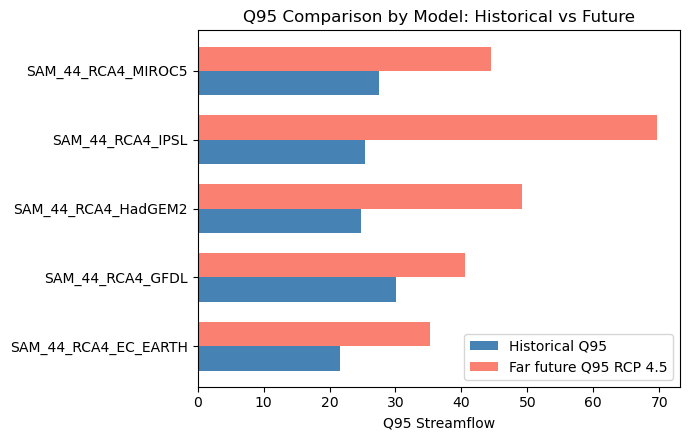

Historical Q95: mean = 25.86, std = 3.17
Future Q95:     mean = 47.82, std = 13.24


In [57]:
# Calculate Q95 per model
q95_hist_models = combined_hist.drop(columns="date").quantile(0.95)
q95_fut_models  = combined_future.drop(columns="date").quantile(0.95)

q95_hist_models.index = q95_hist_models.index.str.replace("historical_", "", regex=False)  # Remove prefixes
q95_fut_models.index  = q95_fut_models.index.str.replace(f"{future_scen}_", "", regex=False)

q95_hist_models, q95_fut_models = q95_hist_models.align(q95_fut_models, join="inner")

models = q95_fut_models.index
y = np.arange(len(models))
height = 0.35

fig, ax = plt.subplots(figsize=(7, len(models) * 0.5 + 2))  

ax.barh(y - height/2, q95_hist_models.values, height, label='Historical Q95', color='steelblue')
ax.barh(y + height/2, q95_fut_models.values, height, label=f'Far future Q95 {scenario}', color='salmon')

ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel("Q95 Streamflow")
ax.set_title("Q95 Comparison by Model: Historical vs Future")
ax.legend()
plt.tight_layout()
plt.show()


# Historical and future Q95 stats
mean_hist_q95 = q95_hist_models.mean()
std_hist_q95  = q95_hist_models.std()
mean_fut_q95 = q95_fut_models.mean()
std_fut_q95  = q95_fut_models.std()

print(f"Historical Q95: mean = {mean_hist_q95:.2f}, std = {std_hist_q95:.2f}")
print(f"Future Q95:     mean = {mean_fut_q95:.2f}, std = {std_fut_q95:.2f}")

### Number of times that threshold (i.e., historical Q95) is exceeded

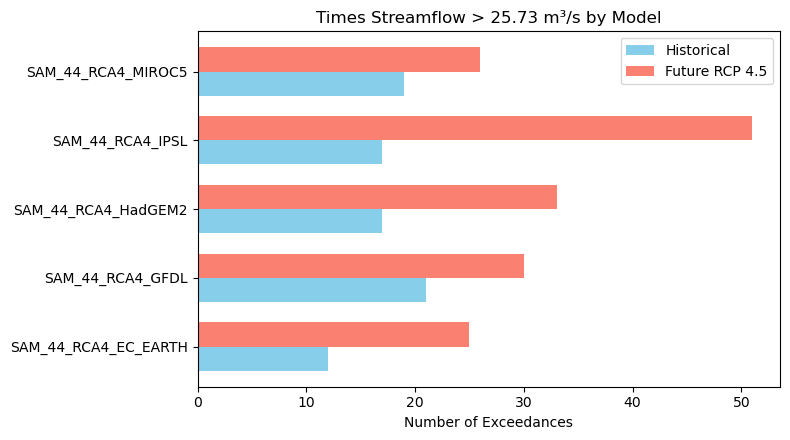

In [58]:
threshold = 25.73 # The user can input this (We introduce historical mean Q95)

# Generating dataframes for each model
hist_df = combined_hist.drop(columns="date", errors="ignore")
fut_df  = combined_future.drop(columns="date", errors="ignore")

# Count exceedances per model
exceed_hist = (hist_df > threshold).sum()
exceed_fut  = (fut_df > threshold).sum()

# Clean and align
exceed_hist.index = exceed_hist.index.str.replace("historical_", "", regex=False)
exceed_fut.index  = exceed_fut.index.str.replace(f"{future_scen}_", "", regex=False)
exceed_hist, exceed_fut = exceed_hist.align(exceed_fut, join="inner")

models = exceed_hist.index
y = np.arange(len(models))
height = 0.35


# Plotting
fig, ax = plt.subplots(figsize=(8, len(models) * 0.5 + 2))

ax.barh(y - height/2, exceed_hist.values, height, label='Historical', color='skyblue')
ax.barh(y + height/2, exceed_fut.values, height, label= f'Future {scenario}', color='salmon')

# Plot properties
ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel("Number of Exceedances")
ax.set_title(f"Times Streamflow > {threshold} m³/s by Model")
ax.legend()
plt.tight_layout()
plt.show()

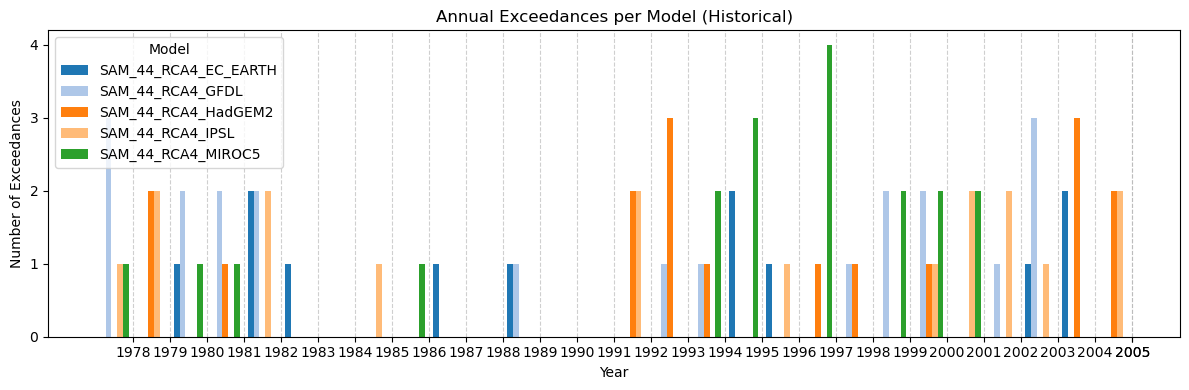

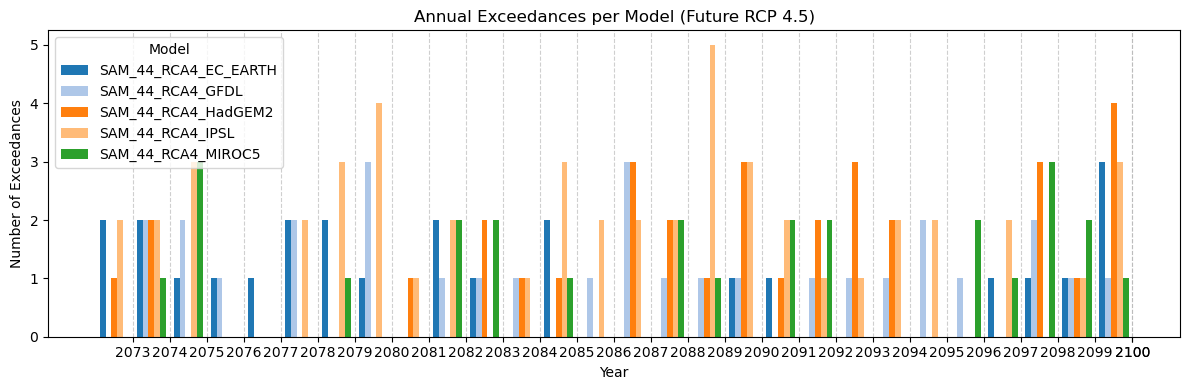

In [59]:
colors = plt.get_cmap("tab20").colors

# Ensure date is index
hist_df = combined_hist.set_index("date") if "date" in combined_hist.columns else combined_hist.copy()
fut_df  = combined_future.set_index("date") if "date" in combined_future.columns else combined_future.copy()

# Group by year and count exceedances per model
exceed_hist_per_year = (hist_df > threshold).groupby(hist_df.index.year).sum()
exceed_fut_per_year  = (fut_df > threshold).groupby(fut_df.index.year).sum()

# Clean and align
exceed_hist_per_year.columns = exceed_hist_per_year.columns.str.replace("historical_", "", regex=False)
exceed_fut_per_year.columns  = exceed_fut_per_year.columns.str.replace(f"{future_scen}_", "", regex=False)

def plot_exceedance_per_year(data, title):
    years = data.index.astype(int)
    models = data.columns
    n_models = len(models)
    x = years.values  # Use actual year values for correct placement
    bar_width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(12, 4))

    for i, model in enumerate(models):
        offset = (i - (n_models - 1) / 2) * bar_width
        ax.bar(x + offset - 0.5, data[model], width=bar_width, label=model, color=colors[i % len(colors)])


    # X-axis ticks at each year
    ax.set_xticks(np.append(years.values, years.values[-1]))  
    ax.set_xticklabels(np.append(years.values, years.values[-1]))

    # Plot properties
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylabel("Number of Exceedances")
    ax.set_xlabel("Year")
    ax.set_title(title)
    ax.legend(title="Model", frameon=True)
    plt.tight_layout()


# Use function to plot
plot_exceedance_per_year(exceed_hist_per_year, f"Annual Exceedances per Model (Historical)")
plot_exceedance_per_year(exceed_fut_per_year, f"Annual Exceedances per Model (Future {scenario})")

### Treshold excedance probability 

In [60]:
# Getting probability for each condition
tep_hist = (combined_hist.drop(columns="date", errors="ignore") > threshold).mean()
tep_fut  = (combined_future.drop(columns="date", errors="ignore") > threshold).mean()

# Clean and align
tep_hist.index = tep_hist.index.str.replace("historical_", "", regex=False)
tep_fut.index  = tep_fut.index.str.replace(f"{future_scen}_", "", regex=False)
tep_hist, tep_fut = tep_hist.align(tep_fut, join="inner")

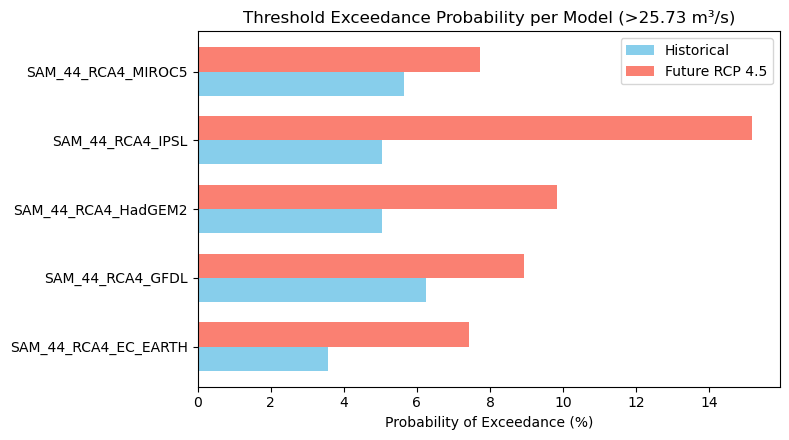

In [61]:
models = tep_hist.index
y = np.arange(len(models))
height = 0.35

fig, ax = plt.subplots(figsize=(8, len(models) * 0.5 + 2))
ax.barh(y - height/2, tep_hist.values * 100, height, label='Historical', color='skyblue')
ax.barh(y + height/2, tep_fut.values  * 100, height, label=f'Future {scenario}', color='salmon')

ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel("Probability of Exceedance (%)")
ax.set_title(f"Threshold Exceedance Probability per Model (>{threshold} m³/s)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Probability of Exceedance curve per model

In [62]:
def plot_dual_poe(hist_df, fut_df, title_hist, title_fut):
    hist_df = hist_df.drop(columns="date", errors="ignore").copy()
    fut_df  = fut_df.drop(columns="date", errors="ignore").copy()

    # Clean prefixes
    hist_df.columns = hist_df.columns.str.replace("historical_", "", regex=False)
    fut_df.columns  = fut_df.columns.str.replace(f"{future_scen}_", "", regex=False)

    # Align columns to make sure models match
    hist_df, fut_df = hist_df.align(fut_df, join="inner", axis=1)

    models = hist_df.columns

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    # Historical
    for i, model in enumerate(models):
        sorted_vals = hist_df[model].sort_values(ascending=False).reset_index(drop=True)
        ranks = np.arange(1, len(sorted_vals) + 1)
        poe = ranks / (len(sorted_vals) + 1)
        ax1.plot(poe * 100, sorted_vals, label=model, color=colors[i % len(colors)],linewidth=1.5)

    ax1.set_xlabel("Probability of Exceedance (%)")
    ax1.set_ylabel("Streamflow (m³/s)")
    ax1.set_title(title_hist)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # Future
    for i, model in enumerate(models):
        sorted_vals = fut_df[model].sort_values(ascending=False).reset_index(drop=True)
        ranks = np.arange(1, len(sorted_vals) + 1)
        poe = ranks / (len(sorted_vals) + 1)
        ax2.plot(poe * 100, sorted_vals, label=model, color=colors[i % len(colors)])

    ax2.set_xlabel("Probability of Exceedance (%)")
    ax2.set_title(title_fut)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()


    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for shared legend
    plt.show()

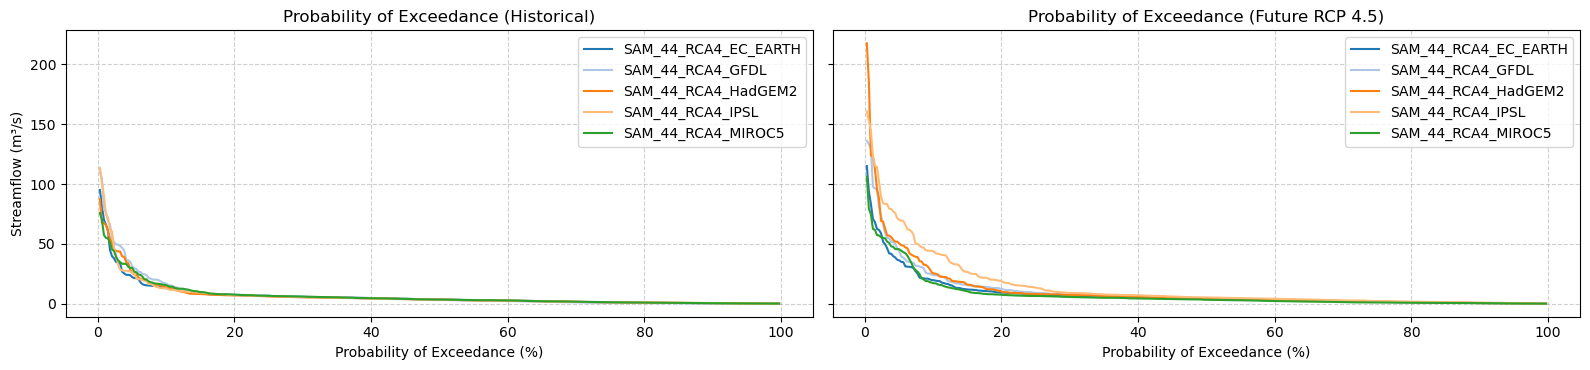

In [63]:
plot_dual_poe(
    combined_hist,
    combined_future,
    "Probability of Exceedance (Historical)",
    f"Probability of Exceedance (Future {scenario})")